In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
TICKER = "TCS.NS"
START  = "2018-01-01"
END    = "2024-12-31"

In [3]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [4]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.sort_index(inplace=True)

In [5]:
print("=== Data Summary ===")
print(f"Ticker       : {TICKER}")
print(f"Trading days : {len(df)}")
print(f"Date range   : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Close range  : ₹{df['Close'].min():.2f} → ₹{df['Close'].max():.2f}")
print(df.tail(3))

=== Data Summary ===
Ticker       : TCS.NS
Trading days : 1726
Date range   : 2018-01-01 → 2024-12-30
Missing vals : 0
Close range  : ₹1077.87 → ₹4311.59
Price              Open         High          Low        Close   Volume
Date                                                                   
2024-12-26  3966.892108  3986.302018  3932.391111  3957.021240  1208464
2024-12-27  3951.231076  3968.268157  3936.282268  3952.987061   858100
2024-12-30  3939.841595  3985.684423  3902.825497  3947.244629  1527169


In [6]:
os.makedirs("data", exist_ok=True)
df.to_csv(f"data/{TICKER.replace('.','_')}_raw.csv")
print("Raw data saved.")

Raw data saved.


## Data Preprocessing

In [7]:
close = df[['Close']].copy()

In [8]:
close.ffill(inplace=True)

Price,Close
Date,
2018-01-01,1083.771484
2018-01-02,1077.872314
2018-01-03,1080.924072
2018-01-04,1088.482422
2018-01-05,1101.632446
...,...
2024-12-23,3946.769775
2024-12-24,3966.891846
2024-12-26,3957.021240


In [9]:
split = int(len(close) * 0.80)
train_data = close[:split]
test_data  = close[split:]

In [10]:
print(f"Train size : {len(train_data)} days")
print(f"Test size  : {len(test_data)} days")

Train size : 1380 days
Test size  : 346 days


In [11]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

In [12]:
WINDOW = 60

In [13]:
def make_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [14]:
X_train, y_train = make_sequences(train_scaled, WINDOW)
X_test,  y_test  = make_sequences(test_scaled,  WINDOW)

In [15]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

In [16]:
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print("Preprocessing complete. Ready for ARIMA and LSTM.")


X_train shape : (1320, 60, 1)
X_test shape  : (286, 60, 1)
y_train shape : (1320,)
Preprocessing complete. Ready for ARIMA and LSTM.


## Visualization

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['lines.linewidth'] = 1.5

In [18]:
print("=== Basic Info ===")
print(df.info())

=== Basic Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 1726 entries, 2018-01-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1726 non-null   float64
 1   High    1726 non-null   float64
 2   Low     1726 non-null   float64
 3   Close   1726 non-null   float64
 4   Volume  1726 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 80.9 KB
None


In [19]:
print("\n=== Descriptive Statistics ===")
print(df['Close'].describe().round(2))
print(f"\nMissing values:\n{df.isnull().sum()}")


=== Descriptive Statistics ===
count    1726.00
mean     2600.84
std       832.05
min      1077.87
25%      1782.21
50%      2810.52
75%      3207.04
max      4311.59
Name: Close, dtype: float64

Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


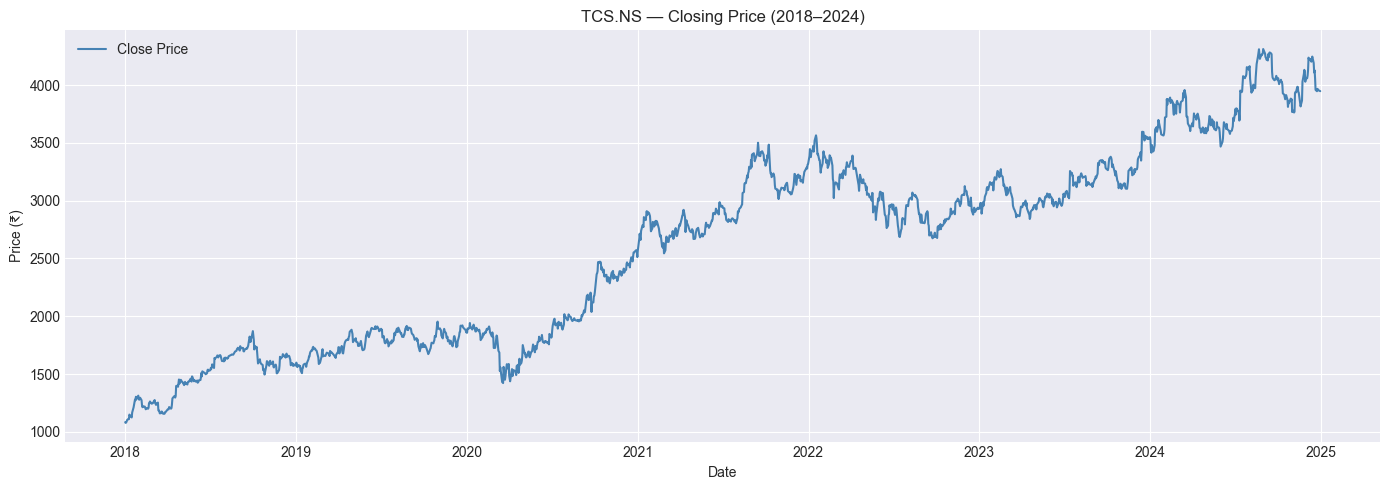

In [20]:
plt.figure()
plt.plot(df.index, df['Close'], color='steelblue', label='Close Price')
plt.title(f'{TICKER} — Closing Price (2018–2024)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/01_closing_price.png', dpi=150)
plt.show()

In [21]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

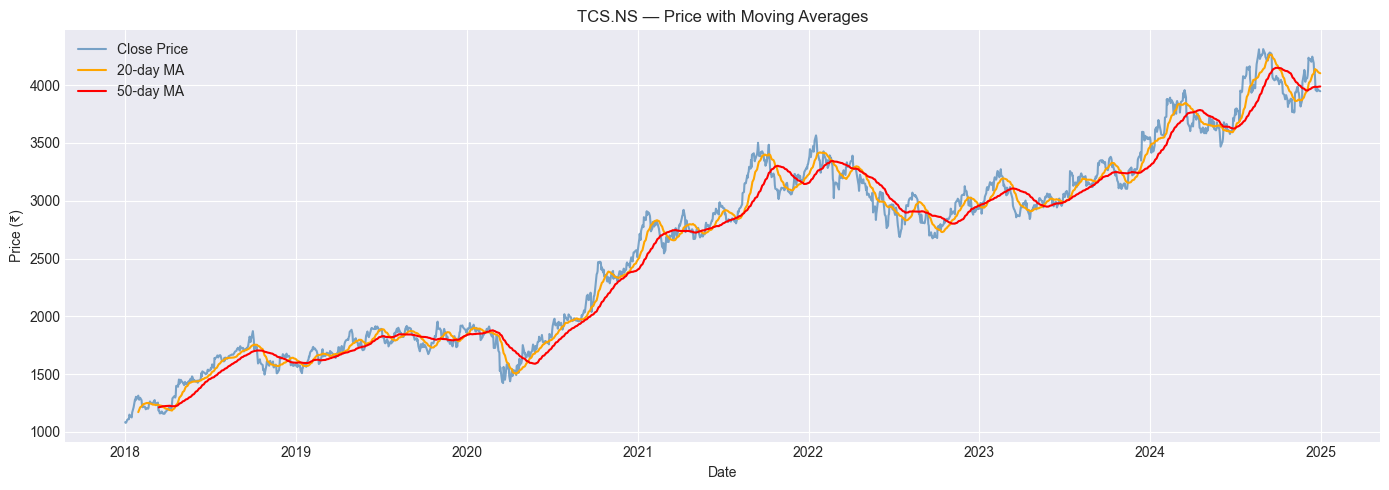

In [22]:
plt.figure()
plt.plot(df['Close'], color='steelblue',  label='Close Price', alpha=0.7)
plt.plot(df['MA20'],  color='orange',     label='20-day MA')
plt.plot(df['MA50'],  color='red',        label='50-day MA')
plt.title(f'{TICKER} — Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/02_moving_averages.png', dpi=150)
plt.show()

In [23]:
df['Daily_Return'] = df['Close'].pct_change() * 100

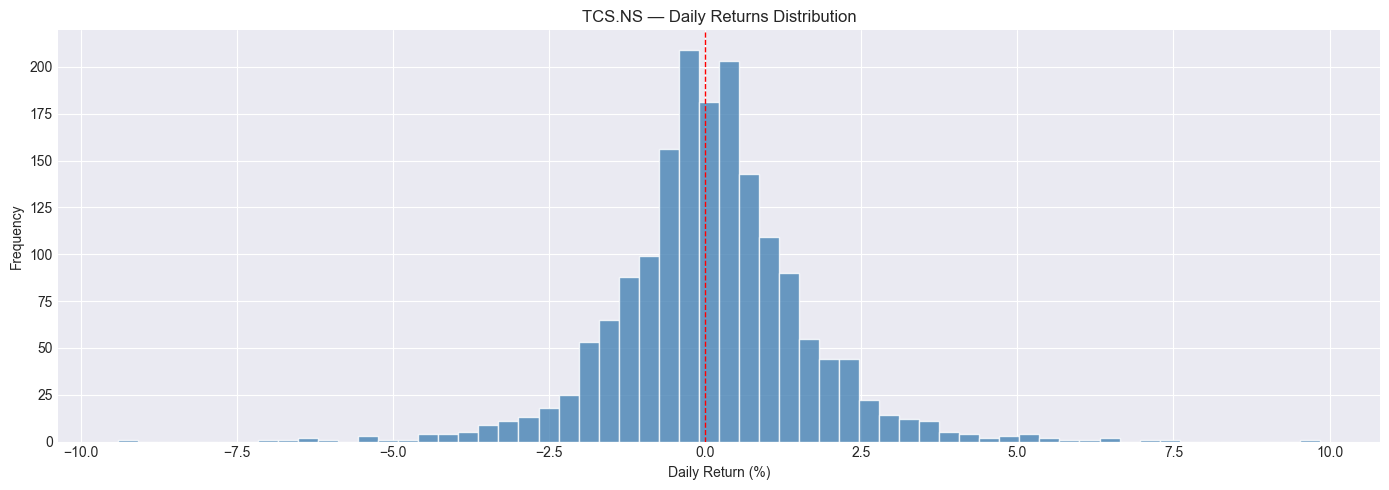

In [24]:
plt.figure()
df['Daily_Return'].hist(bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'{TICKER} — Daily Returns Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/03_daily_returns.png', dpi=150)
plt.show()

In [25]:
print(f"Mean daily return : {df['Daily_Return'].mean():.4f}%")
print(f"Std  daily return : {df['Daily_Return'].std():.4f}%")

Mean daily return : 0.0868%
Std  daily return : 1.5393%


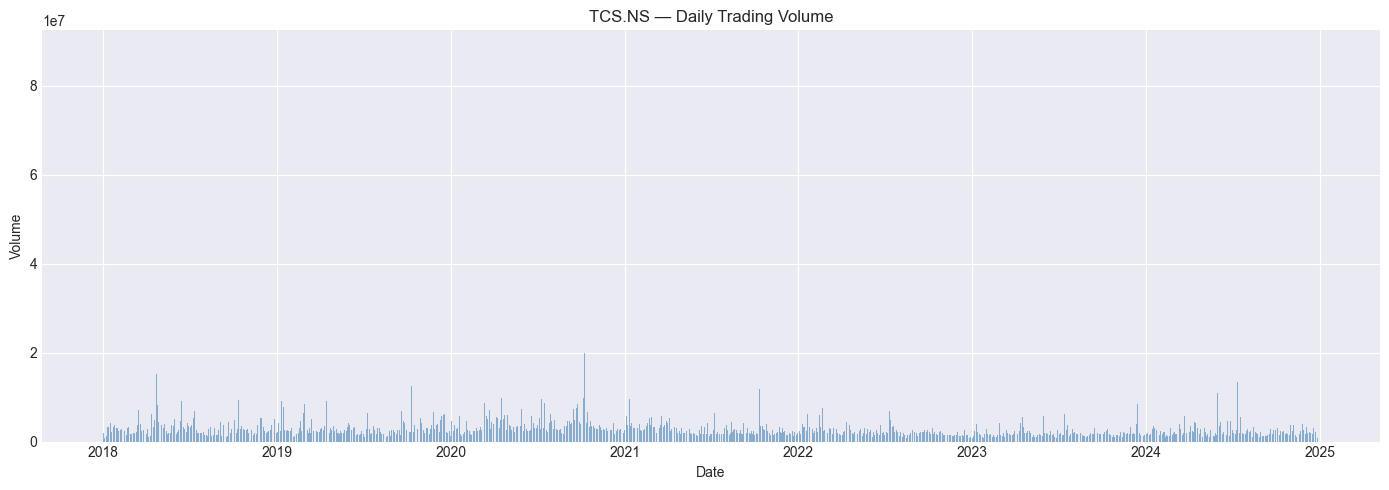

In [26]:
plt.figure()
plt.bar(df.index, df['Volume'], color='steelblue', alpha=0.6, width=1)
plt.title(f'{TICKER} — Daily Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('plots/04_volume.png', dpi=150)
plt.show()

In [27]:
df['Volatility'] = df['Close'].rolling(window=30).std()

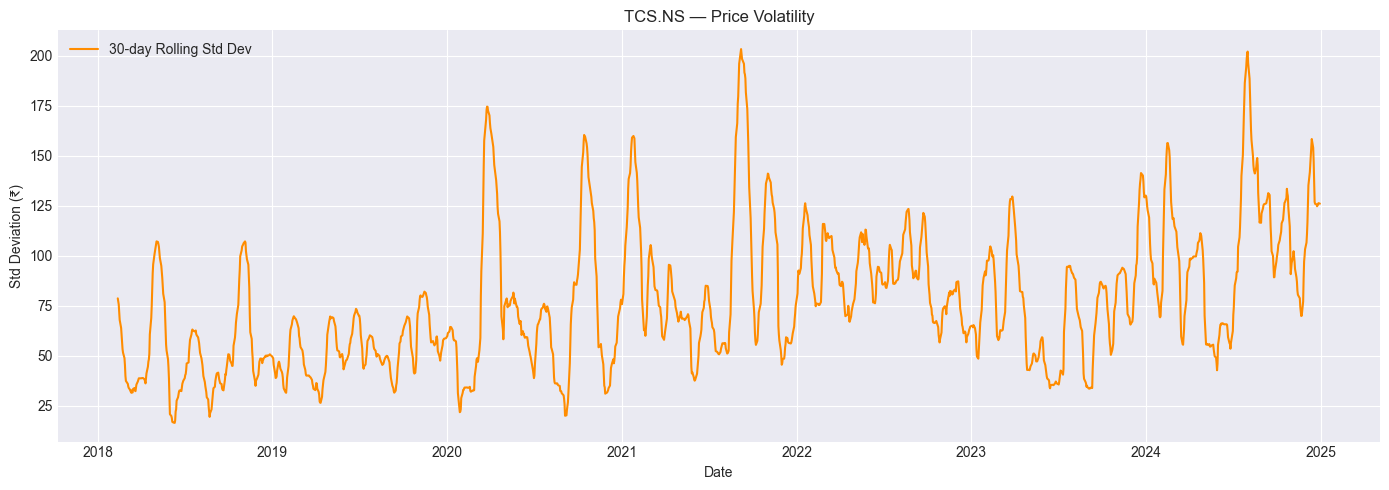

In [28]:
plt.figure()
plt.plot(df['Volatility'], color='darkorange', label='30-day Rolling Std Dev')
plt.title(f'{TICKER} — Price Volatility')
plt.xlabel('Date')
plt.ylabel('Std Deviation (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/05_volatility.png', dpi=150)
plt.show()

In [29]:
df['BB_upper'] = df['MA20'] + 2 * df['Close'].rolling(20).std()
df['BB_lower'] = df['MA20'] - 2 * df['Close'].rolling(20).std()

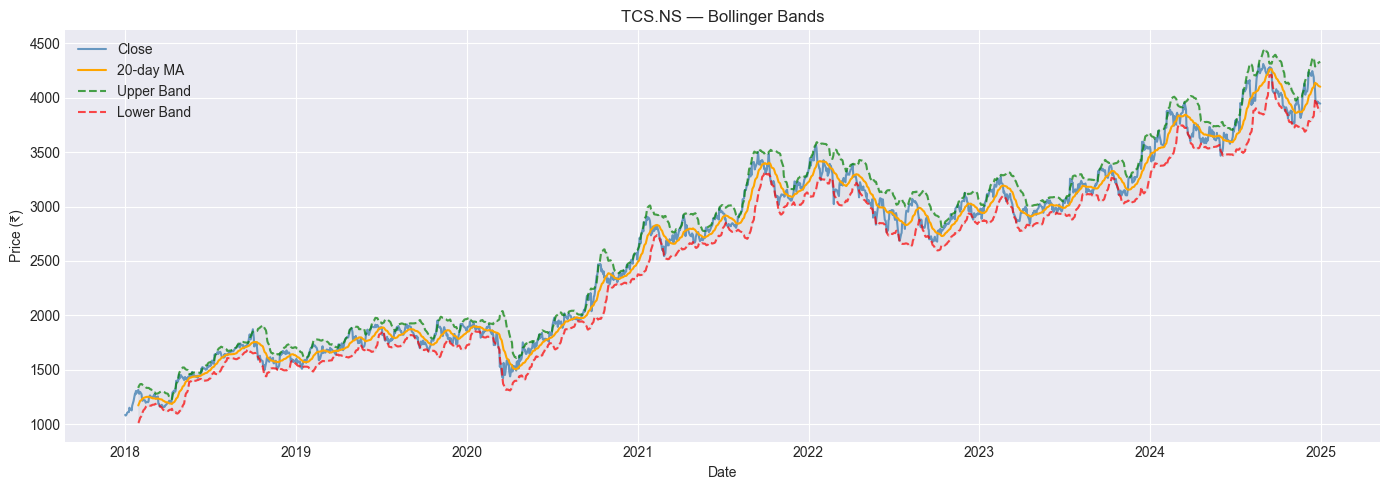

In [30]:
plt.figure()
plt.plot(df['Close'],    color='steelblue', label='Close',        alpha=0.8)
plt.plot(df['MA20'],     color='orange',    label='20-day MA')
plt.plot(df['BB_upper'], color='green',     label='Upper Band',   linestyle='--', alpha=0.7)
plt.plot(df['BB_lower'], color='red',       label='Lower Band',   linestyle='--', alpha=0.7)
plt.fill_between(df.index, df['BB_upper'], df['BB_lower'], alpha=0.07, color='gray')
plt.title(f'{TICKER} — Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/06_bollinger_bands.png', dpi=150)
plt.show()

In [31]:
print("=== Augmented Dickey-Fuller Test ===")
result = adfuller(df['Close'].dropna())
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Conclusion    : {'Stationary' if result[1] < 0.05 else 'NOT stationary — apply differencing'}")

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -1.1390
p-value       : 0.6993
Conclusion    : NOT stationary — apply differencing


In [32]:
result_diff = adfuller(df['Close'].diff().dropna())
print(f"\nAfter 1st differencing:")
print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"p-value       : {result_diff[1]:.4f}")
print(f"Conclusion    : {'Stationary' if result_diff[1] < 0.05 else 'Still NOT stationary'}")


After 1st differencing:
ADF Statistic : -30.0931
p-value       : 0.0000
Conclusion    : Stationary


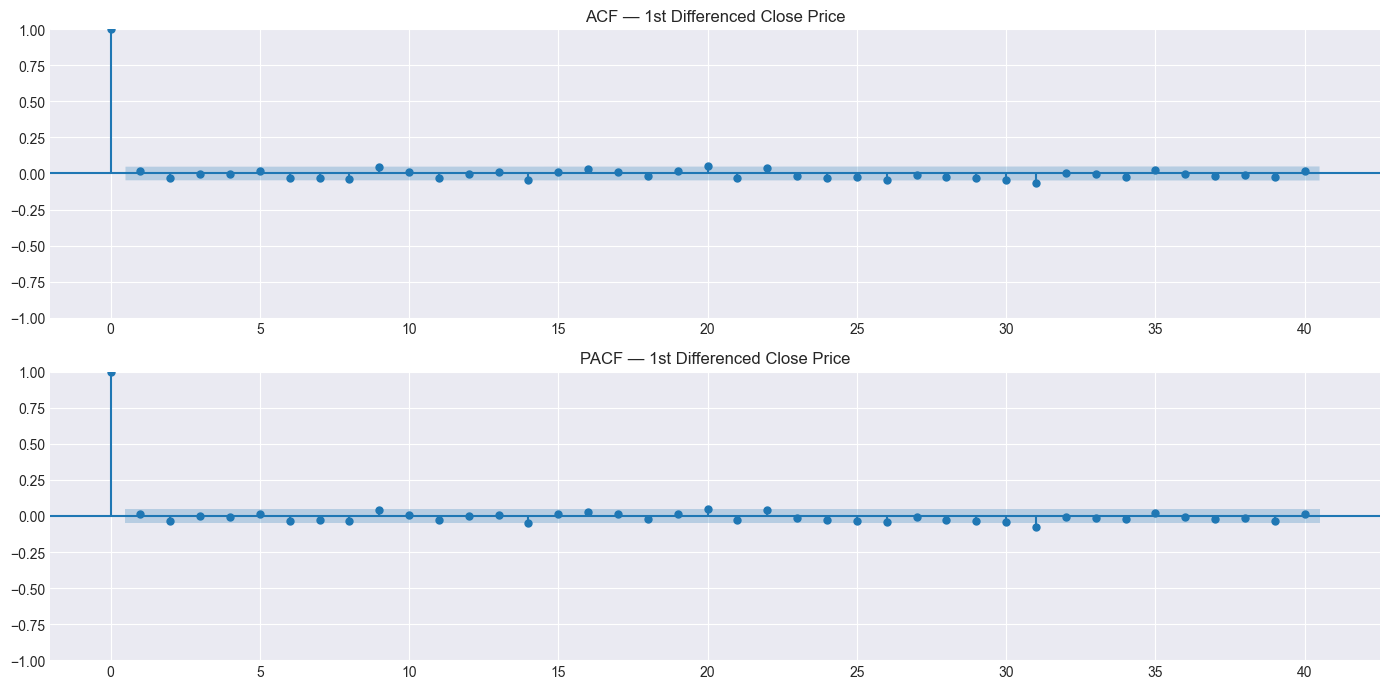

In [33]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(df['Close'].diff().dropna(),  ax=ax1, lags=40, title='ACF — 1st Differenced Close Price')
plot_pacf(df['Close'].diff().dropna(), ax=ax2, lags=40, title='PACF — 1st Differenced Close Price')

plt.tight_layout()
plt.savefig('plots/07_acf_pacf.png', dpi=150)
plt.show()